# Repaired reproducibility version

Derived from the original supplementary notebook. Original plotting/analysis cells are retained; only documented path, environment, missing-helper and unambiguous stale-variable fixes were applied. See `../REPAIR_LOG.md` for every change and items requiring manual confirmation.

In [2]:
source('../shared/r_funcs_repro.r')

# figure s1 vlz

- kernel: r_env, R 4.1.3

## load

In [9]:
library(tidyverse)
library(tools)
library(logging)
library(ggpubr)
library(ggsci)
library(patchwork)
library(igraph)
library(ggraph)
library(Seurat)
library(ComplexHeatmap)

theme_set(theme_pubr())
logging::basicConfig()
options(warn = -1)

outdir <- '../../output/figs1'
create_dir(outdir)

In [10]:
f_pat_gp <- '../../data/tables/patient_info_v2.tsv'
gp <- 'response'

gp_comp_map$response <- list(
  c('R-pre', 'R-post'),
  c('NR-pre', 'NR-post'),
  c('R-pre', 'NR-pre'),
  c('R-post', 'NR-post')
)
gp_lvls$response <- c('R', 'NR')
comb_order <- c('R-pre', 'R-post', 'NR-pre', 'NR-post')

## clinical info: s1a

In [11]:
f_sc_clin <- '../../data/assets/clinical/sc_merge_clinical-230925.xlsx'

In [12]:
df <- readxl::read_xlsx(f_sc_clin, sheet = 'clinical_info') %>% 
    select(patient, treatment_sum, mandard_score) %>% 
    add_clin_info(ftsv = f_pat_gp, columns = c('response', 'response_v2'), merge_by = 'patient')
# %>%
#     mutate(treatment_sum = if_else(treatment_sum == 'NA', 'unknown', treatment_sum),
#            mandard_score = if_else(mandard_score == 'NA', 'unknown', mandard_score),
#            response = if_else(is.na(response), 'unknown', response),
#            response_v2 = if_else(is.na(response_v2), 'Unknown', response))
loginfo('total %g records', nrow(df))
df %>% write_tsv(str_glue('{outdir}/figs1a-clinical_summary.tsv'))

2026-07-18 17:00:43.406387 INFO::these clinial info will be added: response, response_v2
2026-07-18 17:00:43.411033 INFO::total 52 records


In [13]:
p1 <- df %>% 
    count(treatment_sum, .data[[gp]]) %>% 
    mutate(pat_gp = factor(.data[[gp]], gp_lvls[[gp]])) %>%
    ggbarplot(x = 'treatment_sum', y = 'n', fill = 'pat_gp', 
              label = T, lab.vjust = -0.1, alpha = 0.7,
              position = position_dodge(0.7),
              order = c('chemo', 'chemo+immune', 'NA')) +
    scale_fill_jco(na.value = 'gray50') +
    labs(y = 'Number of patients', fill = 'Response') +
    theme(axis.title.x = element_blank(), legend.position = 'right', 
          axis.text.x = element_text(angle = 60, hjust = 0.98))
p2 <- df %>% 
    count(mandard_score, .data[[gp]]) %>% 
    mutate(pat_gp = factor(.data[[gp]], gp_lvls[[gp]])) %>%
    ggbarplot(x = 'mandard_score', y = 'n', fill = 'pat_gp', 
              label = T, lab.vjust = -0.1, alpha = 0.7) +
    scale_fill_jco(na.value = 'gray50') +
    labs(y = 'Number of patients', fill = 'Response') +
    theme(axis.title.x = element_blank(), legend.position = 'right')

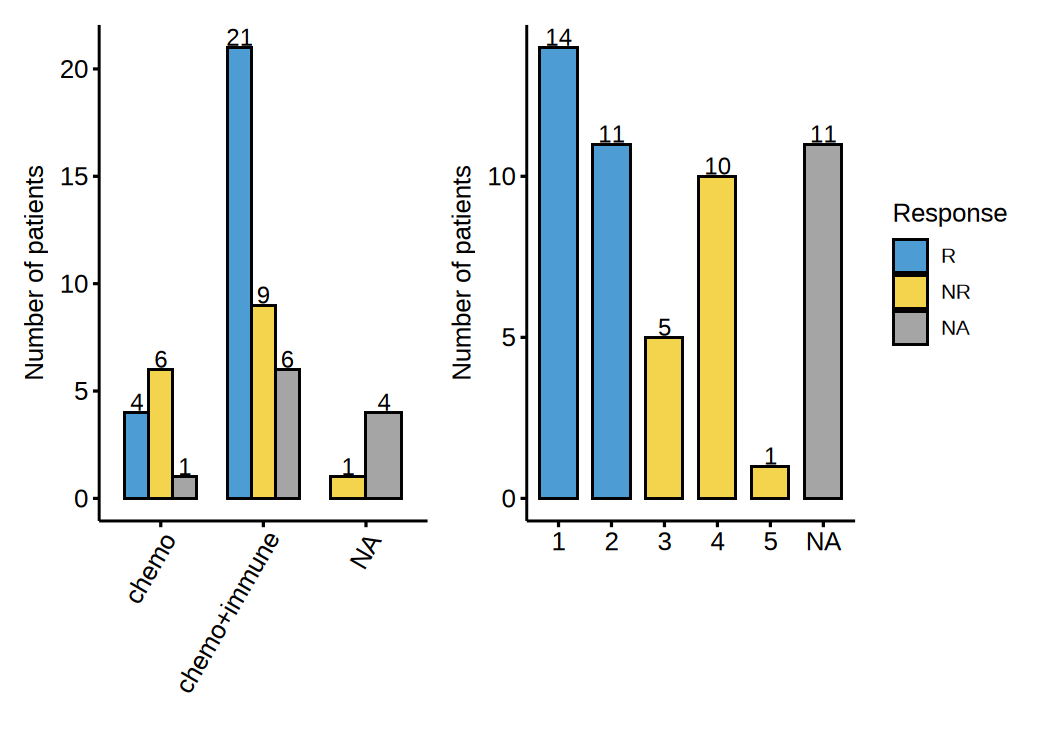

In [14]:
p <- p1 + p2 + plot_layout(guides = 'collect') & theme(legend.position = 'right')
source_data_figs1a <- bind_rows(
    df %>% count(treatment_sum, .data[[gp]]) %>% rename(category = treatment_sum) %>% mutate(panel = 'treatment'),
    df %>% count(mandard_score, .data[[gp]]) %>% rename(category = mandard_score) %>% mutate(panel = 'Mandard score')
)
source_data_figs1a %>% write_tsv(str_glue('{outdir}/figs1a-bar-clin_summary-source_data.tsv'))
ggsave(filename = str_glue('{outdir}/figs1a-bar-clin_summary.pdf'), width = 7, height = 5, plot = p)
jp_opt(wd = 7, hg = 5)
print(p)


## major cell type markers: s1b (require data from GEO)

In [15]:
# f_obj <- '../../data/stage4/a01_data/seuobj/whole.rds'
f_obj <- '../../data/stage4/a01_data/seuobj/whole.rds'
markers <- list(
    'T+NK cells' = c('CD3D', 'CD3E', 'CD3G', 'NKG7'),
    'B cells' = c('CD19', 'MS4A1', 'CD79A', 'CD79B'),
    'Plasma' = c('JCHAIN', 'MZB1', 'XBP1'),
    'Myeloid' = c('CD68', 'CD14', 'LYZ'),
    'Epithelial' = c('EPCAM', 'KRT14', 'KRT15'),
    'Endothelial' = c('PECAM1', 'ICAM1', 'CLDN5'), 
    'Fibroblast' = c('COL1A1', 'COL1A2', 'C1R')
)
ctype_map <- list(
    'T+NK cells' = c('T'),
    'B & Plasma cells' = c('B', 'Plasma')
)
ctype_order <- c('T+NK cells', 'B & Plasma cells', 'Myeloid', 'Epithelial', 'Endothelial', 'Fibroblast')

In [ ]:
scrna <- readRDS(f_obj)
DefaultAssay(scrna) <- 'RNA'

In [6]:
scrna$cellgp <- scrna$cell_type_correct
for (nm in names(ctype_map)) {
    scrna$cellgp[scrna$cell_type_correct %in% ctype_map[[nm]]] <- nm
}
scrna$cellgp <- factor(scrna$cellgp, levels = rev(ctype_order))

In [ ]:
p <- DotPlot(object = scrna, features = markers, group.by = 'cellgp') +
    scale_color_gsea() +
    RotatedAxis() +
    theme(axis.title = element_blank()) 
write_plot_source_data(p, str_glue('{outdir}/figs1b-v3-dot-major_markers-source_data.tsv'))
ggsave(filename = str_glue('{outdir}/figs1b-v3-dot-major_markers.pdf'), plot = p, width = 11, height = 4)
jp_opt(wd = 11, hg = 4)
print(p)

## s1c: umap of major cell types (require data from GEO)

In [ ]:
theme_set(theme_pubr())
outdir <- '../../output/figs1'
title_map <- c(
    'fibro' = 'Fibroblast',
    'endo' = 'Endothelial',
    'b_plasma' = 'B & Plasma cells',
    't' = 'T cells',
    'myeloid' = 'Myeloid',
    'epi' = 'Epithelial',
    'whole' = 'Major cell type'
)
obj_path <- c(
    'fibro' = '../../data/stage4/a01_data/seuobj/fibro.rds',
    'endo' = '../../data/stage4/a01_data/seuobj/endo.rds',
    'b_plasma' = '../../data/stage4/a01_data/seuobj/b_plasma.rds',
    't' = '../../data/stage4/a01_data/seuobj/t.rds',
    'myeloid' = '../../data/stage4/a01_data/seuobj/myeloid.rds',
    'epi' = '../../data/stage4/a01_data/seuobj/epi.rds'
)

In [ ]:
for (nm in names(obj_path)) {
    scrna <- readRDS(obj_path[nm])
    if (nm == 't') {
        scrna$subtype[scrna$subtype == 'T_Prolif'] <- 'T_MKI67'
    }
    color_by <- if_else(nm == 't', 'subtype', if_else(nm == 'whole', 'cell_type_correct', 'cell_type'))
    p <- DimPlot(object = scrna, reduction = 'umap', group.by = color_by, raster = T, shuffle = T,
                 label = T, label.size = 4, cols = scanpy_pal$zeileis_28, repel = T) +
        labs(title = title_map[nm]) +
        theme(axis.line = element_blank(), 
              axis.ticks = element_blank(),
              axis.text = element_blank(),
              axis.title = element_blank(),
              legend.position = 'none')
    write_plot_source_data(p, str_glue('{outdir}/figs1c-umap_celltype-{nm}-source_data.tsv'))
    ggsave(filename = str_glue('{outdir}/figs1c-umap_celltype-{nm}.pdf'), plot = p, width = 5, height = 4)
    jp_opt(wd = 5, hg = 4)
    print(p)
    rm(scrna)
    gc()
}

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

